In [ ]:
!pip3 install -U torch torchvision lightning torchmetrics pillow brevitas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 41.2 MB/s eta 0:00:00


In [ ]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)
CIFAR10_LABELS = {"cat": 3, "dog": 5}

In [ ]:
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
import random
from pathlib import Path
import torch
import lightning as L
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

class TwoClassDataModule(L.LightningDataModule):
    """
    CIFAR-10 → binary split: cat(0) vs dog(1).
    Validation is taken from the TRAIN split (stratified 10% per class),
    TEST is the official test split, filtered for cat/dog only.

    Details:
      - Base datasets are created with transform=None → return PIL.Image
        (avoids "Resize/ToTensor on torch.Tensor" errors).
      - Transforms are applied exactly ONCE at the subset level.
      - pin_memory is enabled only if CUDA is available.
      - num_workers is safely limited to 2 (typical for laptops/Colab).
    """

    # Class-level: CIFAR-10 constants (cat=3, dog=5) and normalization stats
    CIFAR10_LABELS = {"cat": 3, "dog": 5}
    CIFAR10_MEAN   = (0.4914, 0.4822, 0.4465)
    CIFAR10_STD    = (0.2470, 0.2435, 0.2616)

    def __init__(self,
                 workdir: str = "./workdir",
                 batch_size: int = 128,
                 num_workers: int = 4,
                 img_size: int = 224,
                 val_ratio_per_class: float = 0.1,
                 pin_memory: bool | None = None):
        super().__init__()
        self.workdir = Path(workdir)
        self.workdir.mkdir(parents=True, exist_ok=True)

        self.batch_size = batch_size
        self.num_workers = num_workers
        self.img_size = img_size
        self.val_ratio = val_ratio_per_class
        self._pin_memory_cfg = pin_memory  # None → auto based on CUDA

        self.train_ds = self.val_ds = self.test_ds = None
        self.class_names = ["cat", "dog"]

        # Transforms: applied only once in the subset
        self.tf_train = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(self.img_size),
            transforms.ToTensor(),
            transforms.Normalize(self.CIFAR10_MEAN, self.CIFAR10_STD),
        ])
        self.tf_eval = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(self.img_size),
            transforms.ToTensor(),
            transforms.Normalize(self.CIFAR10_MEAN, self.CIFAR10_STD),
        ])

    def setup(self, stage=None):
        # 1) Base datasets WITHOUT transform → return PIL.Image
        tr_base = datasets.CIFAR10(root=str(self.workdir / "cifar10"),
                                   train=True, download=True, transform=None)
        te_base = datasets.CIFAR10(root=str(self.workdir / "cifar10"),
                                   train=False, download=True, transform=None)

        # Helper: indices by label
        def idx_by_label(ds, label):
            return [i for i, (_, y) in enumerate(ds) if y == label]

        cat_idx = idx_by_label(tr_base, self.CIFAR10_LABELS["cat"])
        dog_idx = idx_by_label(tr_base, self.CIFAR10_LABELS["dog"])

        # Stratified train→val split (per class)
        def split_idx(idxs, ratio):
            idxs = idxs[:]  # copy to avoid modifying original list
            random.shuffle(idxs)
            k = max(1, int(len(idxs) * ratio))
            return idxs[k:], idxs[:k]  # train_part, val_part

        cat_tr, cat_val = split_idx(cat_idx, self.val_ratio)
        dog_tr, dog_val = split_idx(dog_idx, self.val_ratio)

        # Remap CIFAR10 labels → {0:cat, 1:dog}
        def remap(y): return 0 if y == self.CIFAR10_LABELS["cat"] else 1

        # Simple subset wrapper with single transform application
        class _SubsetRemap(torch.utils.data.Dataset):
            def __init__(self, base, indices, remap, tf=None):
                self.base, self.indices, self.remap, self.tf = base, indices, remap, tf
            def __len__(self): return len(self.indices)
            def __getitem__(self, i):
                x, y = self.base[self.indices[i]]  # x: PIL.Image (transform=None)
                if self.tf is not None:
                    x = self.tf(x)
                return x, self.remap(y)

        # 2) Build datasets
        self.train_ds = _SubsetRemap(tr_base, cat_tr + dog_tr, remap, tf=self.tf_train)
        self.val_ds   = _SubsetRemap(tr_base, cat_val + dog_val, remap, tf=self.tf_eval)

        keep = {self.CIFAR10_LABELS["cat"], self.CIFAR10_LABELS["dog"]}
        te_idx = [i for i, (_, y) in enumerate(te_base) if y in keep]
        self.test_ds  = _SubsetRemap(te_base, te_idx, remap, tf=self.tf_eval)

    # --- private helper ---
    def _pin_memory_flag(self) -> bool:
        if self._pin_memory_cfg is not None:
            return bool(self._pin_memory_cfg)
        return torch.cuda.is_available()

    # --- DataLoaders ---
    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=min(self.num_workers, 2),   # safe limit for laptops
            pin_memory=self._pin_memory_flag(),
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=min(self.num_workers, 2),
            pin_memory=self._pin_memory_flag(),
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=min(self.num_workers, 2),
            pin_memory=self._pin_memory_flag(),
        )

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch.nn.utils import spectral_norm as apply_sn

import lightning as L
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score

from MobileNetV3 import mobilenetv3_small
from MobileNetV3Brevitas import mobilenetv3_small_quantized


class LitBinaryClassifier(L.LightningModule):
    """
    MobileNetV3-Small -> 2 classes (cat/dog) with built-in regularizations:
      - Dropout in the head (configurable p)
      - Spectral Normalization on the final Linear (optional)
      - Feature noise on embeddings in train()
      - Label smoothing in CrossEntropyLoss
      - Consistency loss: KL(logits(x) || logits(x+ε)) with small noise ε

    Fixes:
      - freeze_backbone: freeze .features, train .classifier (robust to SN)
      - configure_optimizers: only optimize parameters with requires_grad=True
    """

    def __init__(
        self,
        lr: float = 3e-4,
        weight_decay: float = 1e-4,
        pretrained: bool = True,
        freeze_backbone: bool = True,
        # regularizations
        dropout_p: float = 0.2,
        spectral_norm: bool = False,
        feature_noise_sigma: float = 0.0,
        label_smoothing: float = 0.1,
        consistency_lambda: float = 0.0,
        consistency_noise_sigma: float = 0.0,
    ):
        super().__init__()
        self.save_hyperparameters()

        # --- Backbone: MobileNetV3-Small ---
        # weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        # mb = models.mobilenet_v3_small(weights=weights)
        mb = mobilenetv3_small_quantized()
        mb.load_state_dict(torch.load("./trained_models/MobileNetV3Small_INT4_CIFAR-10.pth"))
        in_features = mb.classifier[3].in_features
        # replace the final layer for 2 classes
        mb.classifier[3] = nn.Linear(in_features, 2)

        # configure Dropout (classifier[2] — standard Dropout in v3-small)
        if isinstance(mb.classifier[2], nn.Dropout):
            mb.classifier[2].p = dropout_p
        else:
            mb.classifier = nn.Sequential(
                *list(mb.classifier[:-1]),
                nn.Dropout(dropout_p),
                nn.Linear(in_features, 2),
            )

        # spectral normalization — strictly on the final Linear
        if spectral_norm:
            mb.classifier[3] = apply_sn(mb.classifier[3])

        # freeze: freeze features entirely, only train classifier
        if freeze_backbone:
            for p in mb.features.parameters():
                p.requires_grad = False
            for p in mb.classifier.parameters():
                p.requires_grad = True

        self.backbone = mb

        # add noise to features before classifier (train() only)
        self.feature_noise_sigma = feature_noise_sigma

        # base loss (with label smoothing)
        self.criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

        # consistency regularization
        self.consistency_lambda = consistency_lambda
        self.consistency_noise_sigma = consistency_noise_sigma

        # metrics
        self.train_acc = BinaryAccuracy()
        self.val_acc   = BinaryAccuracy()
        self.test_acc  = BinaryAccuracy()
        self.val_f1    = BinaryF1Score()
        self.test_f1   = BinaryF1Score()

    # --- internal MobileNetV3-Small features forward ---
    def _forward_features(self, x: torch.Tensor) -> torch.Tensor:
        # x = self.backbone.features(x)
        # x = self.backbone.avgpool(x)
        # x = torch.flatten(x, 1)
        # if self.training and self.feature_noise_sigma > 0.0:
        #     x = x + torch.randn_like(x) * self.feature_noise_sigma
        x = self.backbone.features(x)
        x = self.backbone.conv(x)
        x = self.backbone.avgpool(x)
        x = x.view(x.size(0), -1)
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self._forward_features(x)
        return self.backbone.classifier(feats)

    # --- optimizer for trainable parameters only ---
    def configure_optimizers(self):
        trainable = [p for p in self.parameters() if p.requires_grad]
        if len(trainable) == 0:
            raise RuntimeError(
                "No trainable parameters: all requires_grad=False. "
                "Set freeze_backbone=False or check freeze logic."
            )
        return torch.optim.AdamW(trainable, lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)

    # --- Lightning steps ---
    def training_step(self, batch, batch_idx):
        x, y = batch  # y ∈ {0,1}
        logits = self(x)
        loss = self.criterion(logits, y)

        # Consistency: KL( logits(x) || logits(x+ε) )
        if self.consistency_lambda > 0 and self.consistency_noise_sigma > 0:
            with torch.no_grad():
                x_eps = x + torch.randn_like(x) * self.consistency_noise_sigma
            logits_eps = self(x_eps)
            p = F.log_softmax(logits, dim=1)
            q = F.softmax(logits_eps, dim=1)
            kl = F.kl_div(p, q, reduction="batchmean")
            loss = loss + self.consistency_lambda * kl

        preds = torch.argmax(logits, dim=1)
        self.train_acc.update(preds, y)
        self.log("train/loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("train/acc",  self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.val_acc.update(preds, y)
        self.val_f1.update(preds, y)
        self.log("val/loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        self.log("val/acc", self.val_acc.compute(), prog_bar=True)
        self.log("val/f1",  self.val_f1.compute(),  prog_bar=False)
        self.val_acc.reset()
        self.val_f1.reset()

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.test_acc.update(preds, y)
        self.test_f1.update(preds, y)
        self.log("test/loss", loss, on_step=False, on_epoch=True, prog_bar=False)
        return loss

    def on_test_epoch_end(self):
        self.log("test/acc", self.test_acc.compute(), prog_bar=False)
        self.log("test/f1",  self.test_f1.compute(),  prog_bar=False)
        self.test_acc.reset()
        self.test_f1.reset()

    def on_after_backward(self):
        if self.global_step == 0 and self.trainer.is_global_zero:
            n = sum(1 for p in self.parameters() if p.grad is not None)
            print(f"[debug] params with grad after backward: {n}")

In [ ]:
from lightning.pytorch.callbacks import StochasticWeightAveraging

# def make_trainer(root_dir="./runs", epochs=5, precision="16-mixed", callbacks=None, use_swa=False):
#     cbs = callbacks or []
#     if use_swa:
#         cbs = [*cbs, StochasticWeightAveraging(swa_lrs=1e-3)]
#     torch.set_float32_matmul_precision("medium")
#     return L.Trainer(max_epochs=epochs, precision=precision,
#                      accelerator="auto", devices="auto",
#                      log_every_n_steps=10, default_root_dir=root_dir,
#                      callbacks=cbs)
def make_trainer(root_dir="./runs", epochs=5, callbacks=None):
    torch.set_float32_matmul_precision("medium")
    use_cuda = torch.cuda.is_available()
    bf16_ok = use_cuda and torch.cuda.is_bf16_supported()
    precision = "bf16-mixed" if bf16_ok else ("16-mixed" if use_cuda else "32-true")
    return L.Trainer(
        accelerator="gpu" if use_cuda else "cpu",
        devices=1,
        precision=precision,
        max_epochs=epochs,
        log_every_n_steps=10,
        default_root_dir=root_dir,
        callbacks=callbacks or [],
        # num_sanity_val_steps=0,
    )

In [ ]:
def fit_and_validate(model: LitBinaryClassifier, dm: TwoClassDataModule, trainer: L.Trainer):
    trainer.fit(model, datamodule=dm)
    trainer.validate(model, datamodule=dm)
    trainer.test(model, datamodule=dm)

In [ ]:
import time, math, statistics
try:
    import psutil
    _ps = psutil.Process()
except Exception:
    _ps = None

class CollectMetricsCallback(L.Callback):
    def __init__(self):
        super().__init__()
        self.history = []
        self._mem_samples = []
        self._epoch_rec = None

    def on_sanity_check_start(self, trainer, pl_module):
        self._epoch_rec = None
        self._mem_samples = []

    def on_train_epoch_start(self, trainer, pl_module):
        self._epoch_rec = {"epoch": int(trainer.current_epoch)}
        self._mem_samples = []
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

    def _sample_mem(self):
        if torch.cuda.is_available():
            return int(torch.cuda.memory_allocated())   # current
        elif _ps is not None:
            return int(_ps.memory_info().rss)
        else:
            return 0

    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        self._mem_samples.append(self._sample_mem())

    def on_validation_batch_end(self, trainer, pl_module, outputs, batch, batch_idx, dataloader_idx=0):
        self._mem_samples.append(self._sample_mem())

    def on_validation_epoch_end(self, trainer, pl_module):
        if getattr(trainer, "sanity_checking", False):
            return

        if self._epoch_rec is None:
            self._epoch_rec = {"epoch": int(trainer.current_epoch)}

        for k, v in trainer.callback_metrics.items():
            if isinstance(k, str) and (k.startswith("train/") or k.startswith("val/")):
                if isinstance(v, torch.Tensor):
                    v = float(v.detach().cpu().item())
                else:
                    try: v = float(v)
                    except: continue
                self._epoch_rec[k] = v

        if self._mem_samples:
            self._epoch_rec["mem/min"] = int(min(self._mem_samples))
            self._epoch_rec["mem/avg"] = int(sum(self._mem_samples) / len(self._mem_samples))
            self._epoch_rec["mem/max"] = int(max(self._mem_samples))
        if torch.cuda.is_available():
            self._epoch_rec["mem/peak"] = int(torch.cuda.max_memory_allocated())  # docs: max_memory_allocated

        self.history.append(self._epoch_rec)
        self._epoch_rec = None
        self._mem_samples = []

    def on_test_epoch_end(self, trainer, pl_module):
        rec = {"epoch": "test"}
        for k, v in trainer.callback_metrics.items():
            if isinstance(k, str) and k.startswith("test/"):
                if isinstance(v, torch.Tensor):
                    v = float(v.detach().cpu().item())
                else:
                    try: v = float(v)
                    except: continue
                rec[k] = v
        self.history.append(rec)

In [ ]:
def get_epoch_metrics_df(metrics_cb: CollectMetricsCallback):
    import pandas as pd
    if not metrics_cb.history:
        raise RuntimeError("Metric history is empty.")
    df = pd.DataFrame(metrics_cb.history)
    return df

def plot_epoch_metrics(df):
    import matplotlib.pyplot as plt
    for col in df.columns:
        if col in ("epoch",):
            continue
        # separate plot for each metric (required by the task)
        plt.figure()
        plt.plot(df["epoch"], df[col])
        plt.xlabel("epoch")
        plt.ylabel(col)
        plt.title(col)
        plt.grid(True)
        plt.show()

In [ ]:
metrics_cb = CollectMetricsCallback()
dm = TwoClassDataModule(workdir="./workdir", batch_size=128, num_workers=4, img_size=224)
dm.setup()

model = LitBinaryClassifier(
    lr=3e-4, weight_decay=1e-4,
    pretrained=True, freeze_backbone=True,
    dropout_p=0.3,
    spectral_norm=False,
    feature_noise_sigma=0.0,
    label_smoothing=0.1,
    consistency_lambda=0.0,
    consistency_noise_sigma=0.0
)

trainer = make_trainer(root_dir="./runs/cifar10_catdog", epochs=6, callbacks=[metrics_cb])


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
fit_and_validate(model, dm, trainer)

INFO: 
  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | backbone  | MobileNetV3      | 1.5 M  | train
1 | criterion | CrossEntropyLoss | 0      | train
2 | train_acc | BinaryAccuracy   | 0      | train
3 | val_acc   | BinaryAccuracy   | 0      | train
4 | test_acc  | BinaryAccuracy   | 0      | train
5 | val_f1    | BinaryF1Score    | 0      | train
6 | test_f1   | BinaryF1Score    | 0      | train
-------------------------------------------------------
592 K     Trainable params
927 K     Non-trainable params
1.5 M     Total params
6.080     Total estimated model params size (MB)
215       Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | backbone  | MobileNetV3      | 1.5 M  | train
1 | criterion | CrossEntropyLoss | 0      | train
2 | train_acc | BinaryAccuracy   |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

[debug] params with grad after backward: 4


Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO: `Trainer.fit` stopped: `max_epochs=6` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=6` reached.


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val/acc          │    0.7039999961853027     │
│          val/f1           │    0.5945205688476562     │
│         val/loss          │    0.5754916667938232     │
└───────────────────────────┴───────────────────────────┘

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.6995000243186951     │
│          test/f1          │    0.5952861905097961     │
│         test/loss         │    0.5853775143623352     │
└───────────────────────────┴───────────────────────────┘

In [ ]:
df = get_epoch_metrics_df(metrics_cb); df.tail()

,epoch,val/loss,mem/min,mem/avg,mem/max,val/acc,val/f1,train/loss,train/acc,test/loss
3,3,0.595774,2.526798e+09,2.574051e+09,2.580038e+09,0.732,0.660760,0.454033,0.833778,NaN
4,4,0.610815,2.526826e+09,2.572846e+09,2.582696e+09,0.685,0.561891,0.441189,0.845778,NaN
5,5,0.590169,2.520240e+09,2.573896e+09,2.582589e+09,0.669,0.527817,0.428134,0.853889,NaN
6,6,0.575492,2.504245e+09,2.523992e+09,2.543378e+09,NaN,NaN,NaN,NaN,NaN
7,test,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.585378


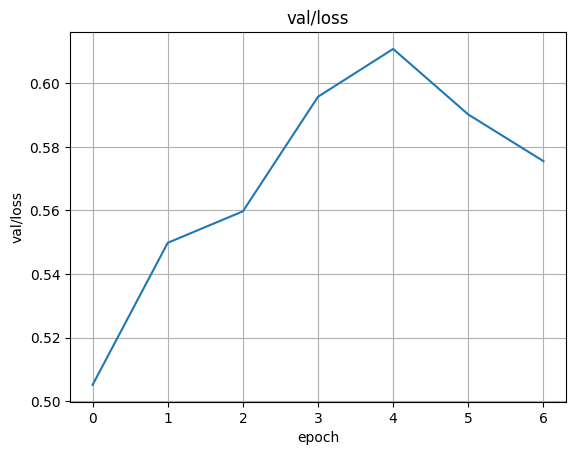

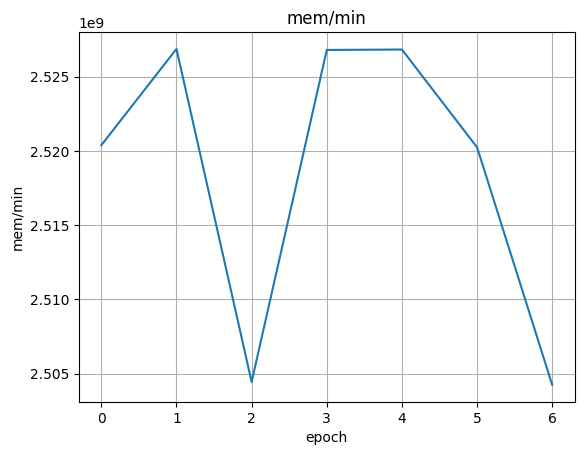

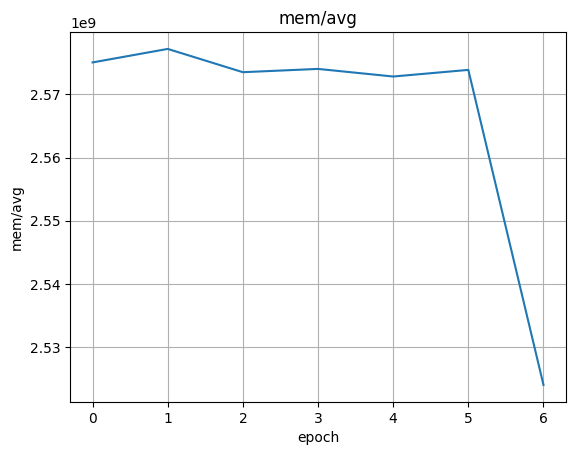

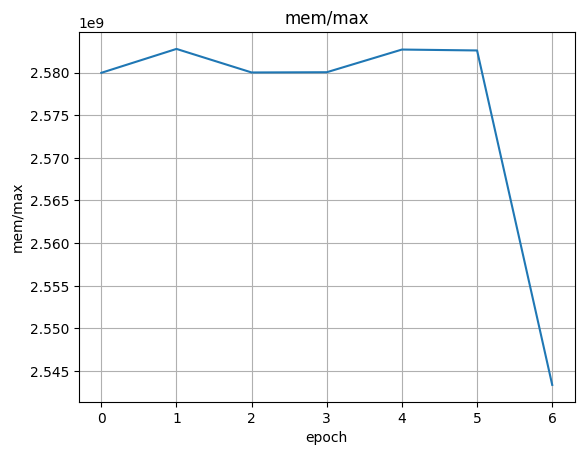

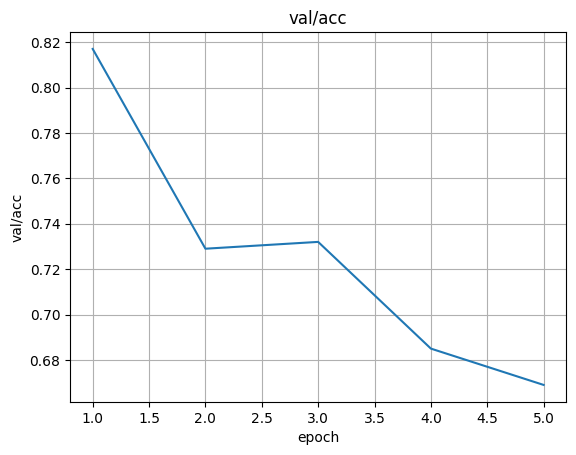

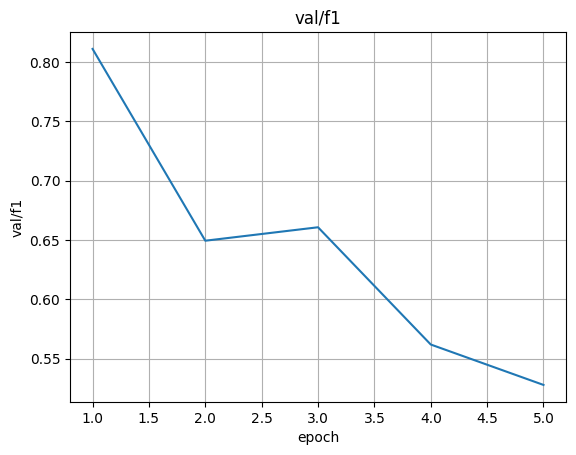

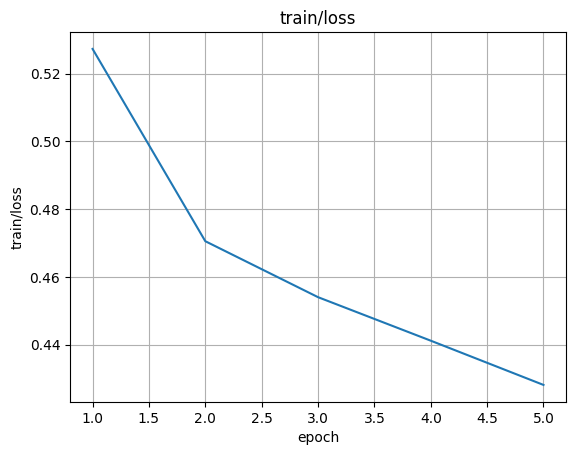

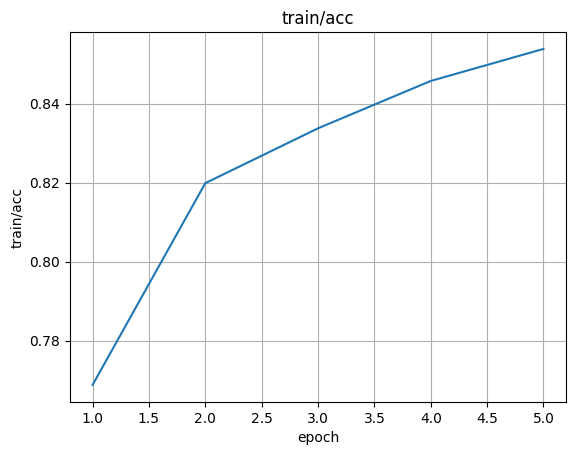

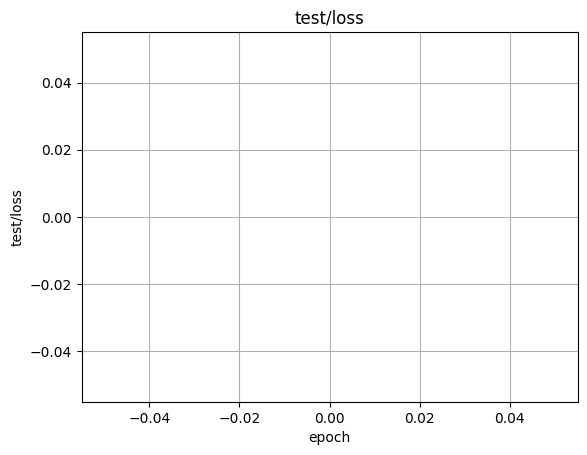

In [ ]:
plot_epoch_metrics(df[:-1])

# test some regularization methods

In [ ]:
# ============================================================
# CIFAR-10 (cat/dog) + modular blocks + Jacobian fix (Hardswish/Hardsigmoid -> SiLU/Sigmoid)
# ============================================================

import os, math, random, statistics, json
from pathlib import Path
from copy import deepcopy
from typing import Iterable

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from torch.nn.utils import spectral_norm as apply_sn

import lightning as L
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score
import pandas as pd

# -----------------------------
# CIFAR-10 constants
# -----------------------------
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)
CIFAR10_LABELS = {"cat": 3, "dog": 5}


# ============================================================
# DataModule: CIFAR-10 → binary classification cat vs dog
# ============================================================
class TwoClassDataModule(L.LightningDataModule):
    CIFAR10_LABELS = CIFAR10_LABELS
    CIFAR10_MEAN   = CIFAR10_MEAN
    CIFAR10_STD    = CIFAR10_STD

    def __init__(self,
                 workdir: str = "./workdir",
                 batch_size: int = 128,
                 num_workers: int = 4,
                 img_size: int = 224,
                 val_ratio_per_class: float = 0.1,
                 pin_memory: bool | None = None):
        super().__init__()
        self.workdir = Path(workdir); self.workdir.mkdir(parents=True, exist_ok=True)
        self.batch_size, self.num_workers = batch_size, num_workers
        self.img_size, self.val_ratio = img_size, val_ratio_per_class
        self._pin_memory_cfg = pin_memory

        self.tf_train = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(self.img_size),
            transforms.ToTensor(),
            transforms.Normalize(self.CIFAR10_MEAN, self.CIFAR10_STD),
        ])
        self.tf_eval = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(self.img_size),
            transforms.ToTensor(),
            transforms.Normalize(self.CIFAR10_MEAN, self.CIFAR10_STD),
        ])

        self.train_ds = self.val_ds = self.test_ds = None
        self.class_names = ["cat", "dog"]

    def setup(self, stage=None):
        tr_base = datasets.CIFAR10(root=str(self.workdir/"cifar10"), train=True,  download=True, transform=None)
        te_base = datasets.CIFAR10(root=str(self.workdir/"cifar10"), train=False, download=True, transform=None)

        def idx_by_label(ds, label): return [i for i,(_,y) in enumerate(ds) if y==label]
        cat_idx = idx_by_label(tr_base, self.CIFAR10_LABELS["cat"])
        dog_idx = idx_by_label(tr_base, self.CIFAR10_LABELS["dog"])

        def split_idx(idxs, ratio):
            idxs = idxs[:]; random.shuffle(idxs)
            k = max(1, int(len(idxs)*ratio))
            return idxs[k:], idxs[:k]

        cat_tr, cat_val = split_idx(cat_idx, self.val_ratio)
        dog_tr, dog_val = split_idx(dog_idx, self.val_ratio)

        def remap(y): return 0 if y==self.CIFAR10_LABELS["cat"] else 1

        class _SubsetRemap(torch.utils.data.Dataset):
            def __init__(self, base, indices, remap, tf=None):
                self.base, self.indices, self.remap, self.tf = base, indices, remap, tf
            def __len__(self): return len(self.indices)
            def __getitem__(self, i):
                x, y = self.base[self.indices[i]]  # PIL.Image (transform=None)
                if self.tf is not None: x = self.tf(x)
                return x, self.remap(y)

        self.train_ds = _SubsetRemap(tr_base, cat_tr+dog_tr, remap, tf=self.tf_train)
        self.val_ds   = _SubsetRemap(tr_base, cat_val+dog_val, remap, tf=self.tf_eval)

        keep = {self.CIFAR10_LABELS["cat"], self.CIFAR10_LABELS["dog"]}
        te_idx = [i for i,(_,y) in enumerate(te_base) if y in keep]
        self.test_ds  = _SubsetRemap(te_base, te_idx, remap, tf=self.tf_eval)

    def _pin_memory_flag(self) -> bool:
        return self._pin_memory_cfg if self._pin_memory_cfg is not None else torch.cuda.is_available()

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True,
                          num_workers=min(self.num_workers, 2), pin_memory=self._pin_memory_flag())
    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False,
                          num_workers=min(self.num_workers, 2), pin_memory=self._pin_memory_flag())
    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False,
                          num_workers=min(self.num_workers, 2), pin_memory=self._pin_memory_flag())

# ============================================================
# Blocks (MixUp/CutMix, optimizer, Jacobian, pruning, EMA, temp, noise-avg)
# ============================================================

class BatchAugmentor:
    def __init__(self,
                 mixup_alpha: float = 0.2,
                 cutmix_alpha: float = 1.0,
                 p: float = 1.0,
                 mode_prior: tuple[float,float] = (0.5, 0.5),
                 apply_on_train_only: bool = True):
        self.mixup_alpha = mixup_alpha
        self.cutmix_alpha = cutmix_alpha
        self.p = p
        self.mode_prior = mode_prior
        self.apply_on_train_only = apply_on_train_only

    @staticmethod
    def _rand_bbox(W, H, lam):
        cut_rat = math.sqrt(1. - lam)
        cut_w = int(W * cut_rat); cut_h = int(H * cut_rat)
        cx = random.randint(0, W); cy = random.randint(0, H)
        x1 = max(cx - cut_w // 2, 0); y1 = max(cy - cut_h // 2, 0)
        x2 = min(cx + cut_w // 2, W); y2 = min(cy + cut_h // 2, H)
        return x1, y1, x2, y2

    def _mixup(self, x, y):
        lam = torch.distributions.Beta(self.mixup_alpha, self.mixup_alpha).sample().item()
        idx = torch.randperm(x.size(0), device=x.device)
        x_mix = lam * x + (1 - lam) * x[idx]
        return x_mix, y, y[idx], lam, "mixup"

    def _cutmix(self, x, y):
        lam = torch.distributions.Beta(self.cutmix_alpha, self.cutmix_alpha).sample().item()
        idx = torch.randperm(x.size(0), device=x.device)
        x_perm = x[idx]
        B, C, H, W = x.size()
        x1, y1, x2, y2 = self._rand_bbox(W, H, lam)
        x_aug = x.clone(); x_aug[:, :, y1:y2, x1:x2] = x_perm[:, :, y1:y2, x1:x2]
        lam_adj = 1.0 - ((x2 - x1) * (y2 - y1) / (W * H))
        return x_aug, y, y[idx], lam_adj, "cutmix"

    def __call__(self, x, y, *, training: bool = True):
        if self.apply_on_train_only and not training:
            return x, y, None, None, "none"
        if random.random() > self.p:
            return x, y, None, None, "none"
        if random.random() < self.mode_prior[0]:
            return self._mixup(x, y)
        else:
            return self._cutmix(x, y)

def mixup_criterion(ce_loss_fn, logits, y, y_perm=None, lam: float | None = None):
    if y_perm is None or lam is None:
        return ce_loss_fn(logits, y)
    return lam * ce_loss_fn(logits, y) + (1.0 - lam) * ce_loss_fn(logits, y_perm)

def _is_norm_module(m):
    return isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d,
                          nn.GroupNorm, nn.LayerNorm, nn.InstanceNorm1d,
                          nn.InstanceNorm2d, nn.InstanceNorm3d))

def parameter_groups(model,
                     base_lr: float,
                     weight_decay: float,
                     layer_decay: float | None = None):
    no_decay, decay = [], []
    for name, module in model.named_modules():
        for pname, p in module.named_parameters(recurse=False):
            if not p.requires_grad:
                continue
            if pname.endswith("bias") or _is_norm_module(module):
                no_decay.append(p)
            else:
                decay.append(p)

    groups = []
    if layer_decay is None:
        groups = [
            {"params": decay, "lr": base_lr, "weight_decay": weight_decay},
            {"params": no_decay, "lr": base_lr, "weight_decay": 0.0},
        ]
    else:
        layers = list(model.backbone.features) if hasattr(model, "backbone") else []
        depth = len(layers)
        for i, layer in enumerate(layers):
            lrd = layer_decay ** (depth - 1 - i)
            d_params = [p for p in layer.parameters() if p.requires_grad]
            if d_params:
                groups.append({"params": d_params, "lr": base_lr * lrd, "weight_decay": weight_decay})
        cls_decay, cls_nodecay = [], []
        for n, p in model.backbone.classifier.named_parameters():
            if not p.requires_grad: continue
            (cls_nodecay if n.endswith("bias") else cls_decay).append(p)
        if cls_decay:
            groups.append({"params": cls_decay, "lr": base_lr, "weight_decay": weight_decay})
        if cls_nodecay:
            groups.append({"params": cls_nodecay, "lr": base_lr, "weight_decay": 0.0})
    return groups

def build_optimizer(model, lr: float = 3e-4, weight_decay: float = 1e-4, layer_decay: float | None = None):
    groups = parameter_groups(model, lr, weight_decay, layer_decay)
    from torch.optim import AdamW
    return AdamW(groups, lr=lr, weight_decay=0.0)

class JacobianRegularizer:
    def __init__(self, lam: float = 0.0, subbatch: int = 8):
        self.lam = lam; self.subbatch = subbatch
    def __call__(self, model, x):
        if self.lam <= 0: return 0.0 * x.sum()
        was_training = model.training; model.train()
        B = x.size(0); tot = 0.0
        for i in range(0, B, self.subbatch):
            xs = x[i:i+self.subbatch].detach().clone().requires_grad_(True)
            logits = model(xs)
            top = logits.max(dim=1).values.sum()
            grads = torch.autograd.grad(top, xs, create_graph=True, retain_graph=True, allow_unused=False)[0]
            tot = tot + (grads.pow(2).sum(dim=(1,2,3)).mean())
        if not was_training: model.eval()
        return self.lam * tot

# ---- Jacobian FIX: safe replacement of activations for double-backward ----
def replace_activations_for_double_backward(model: nn.Module):
    """
    Replaces problematic activations:
      - nn.Hardswish -> nn.SiLU
      - nn.Hardsigmoid -> nn.Sigmoid
    Should be called once BEFORE training if Jacobian reg is enabled.
    """
    for parent in model.modules():
        for name, child in list(parent.named_children()):
            if isinstance(child, nn.Hardswish):
                setattr(parent, name, nn.SiLU(inplace=getattr(child, "inplace", False)))
            elif isinstance(child, nn.Hardsigmoid):
                setattr(parent, name, nn.Sigmoid())
    return model

import torch.nn.utils.prune as prune
class PruningCallback(L.Callback):
    def __init__(self, amount: float = 0.3, start_epoch: int = 1, reapply_each_epoch: bool = False):
        super().__init__()
        self.amount, self.start_epoch, self.reapply, self._applied = amount, start_epoch, reapply_each_epoch, False
    def _target(self, pl_module):
        return pl_module.backbone.classifier[3]
    def on_train_epoch_start(self, trainer, pl_module):
        epoch = trainer.current_epoch
        if epoch < self.start_epoch: return
        if self._applied and not self.reapply: return
        lin = self._target(pl_module)
        try: prune.remove(lin, 'weight')
        except Exception: pass
        prune.l1_unstructured(lin, name='weight', amount=self.amount)
        self._applied = True
    def on_fit_end(self, trainer, pl_module):
        if not self._applied: return
        prune.remove(self._target(pl_module), 'weight')

class EMAWeightsCallback(L.Callback):
    def __init__(self, decay: float = 0.999):
        super().__init__()
        self.decay = decay
        self.shadow: dict[str, torch.Tensor] = {}
        self._backup: dict[str, torch.Tensor] | None = None

    def _ensure_shadow_init(self, pl_module):
        cur = pl_module.state_dict()
        if not self.shadow or (self.shadow.keys() ^ cur.keys()):
            self.shadow = {k: v.detach().clone() for k, v in cur.items()}

    def on_sanity_check_start(self, trainer, pl_module):
        self._ensure_shadow_init(pl_module)

    def on_train_start(self, trainer, pl_module):
        self._ensure_shadow_init(pl_module)

    def on_after_backward(self, trainer, pl_module):
        with torch.no_grad():
            for k, v in pl_module.state_dict().items():
                if torch.is_floating_point(v):
                    self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1.0 - self.decay)
                else:
                    self.shadow[k] = v.detach().clone()

    def _swap_to(self, pl_module, src: dict[str, torch.Tensor]):
        current = pl_module.state_dict()
        pl_module.load_state_dict(src, strict=True)
        return current

    def on_validation_start(self, trainer, pl_module):
        self._backup = self._swap_to(pl_module, self.shadow)

    def on_validation_end(self, trainer, pl_module):
        if self._backup is not None:
            pl_module.load_state_dict(self._backup, strict=True)
            self._backup = None

    def on_test_start(self, trainer, pl_module):
        self._backup = self._swap_to(pl_module, self.shadow)

    def on_test_end(self, trainer, pl_module):
        if self._backup is not None:
            pl_module.load_state_dict(self._backup, strict=True)
            self._backup = None

class TemperatureScaler(nn.Module):
    def __init__(self): super().__init__(); self.log_T = nn.Parameter(torch.zeros(()))
    @property
    def T(self): return self.log_T.exp()
    def forward(self, logits): return logits / self.T
    @torch.no_grad()
    def fit(self, model, val_loader, device=None):
        device = device or next(model.parameters()).device
        self.to(device)
        opt = torch.optim.LBFGS([self.log_T], lr=0.01, max_iter=50, line_search_fn="strong_wolfe")
        nll = nn.CrossEntropyLoss()
        def _eval_loss():
            total, count = 0.0, 0
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                logits = model(x)
                total += float(nll(self.forward(logits), y).item()) * x.size(0)
                count += x.size(0)
            return total / max(count,1)
        def closure():
            opt.zero_grad(set_to_none=True)
            loss = torch.tensor(_eval_loss(), device=device, requires_grad=True)
            loss.backward(); return loss
        opt.step(closure); return float(self.T.item())

@torch.no_grad()
def predict_with_noise_avg(model, x, n_samples: int = 8, sigma: float = 0.05):
    device = next(model.parameters()).device
    x = x.to(device)
    logits_sum = None
    for _ in range(n_samples):
        eps = torch.randn_like(x) * sigma
        logits = model(x + eps)
        logits_sum = logits if logits_sum is None else (logits_sum + logits)
    return logits_sum / float(n_samples)


# ============================================================
# Model: MobileNetV3-Small → 2 classes
# ============================================================
class LitBinaryClassifier(L.LightningModule):
    def __init__(self,
                 lr: float = 3e-4,
                 weight_decay: float = 1e-4,
                 pretrained: bool = True,
                 freeze_backbone: bool = True,
                 dropout_p: float = 0.2,
                 spectral_norm: bool = False,
                 feature_noise_sigma: float = 0.0,
                 label_smoothing: float = 0.1,
                 consistency_lambda: float = 0.0,
                 consistency_noise_sigma: float = 0.0,
                 use_custom_optimizer: bool = True,
                 layer_decay: float | None = None):
        super().__init__()
        self.save_hyperparameters()

        weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        mb = models.mobilenet_v3_small(weights=weights)
        in_features = mb.classifier[3].in_features
        mb.classifier[3] = nn.Linear(in_features, 2)
        if isinstance(mb.classifier[2], nn.Dropout):
            mb.classifier[2].p = dropout_p
        else:
            mb.classifier = nn.Sequential(*list(mb.classifier[:-1]), nn.Dropout(dropout_p), nn.Linear(in_features, 2))
        if spectral_norm:
            mb.classifier[3] = apply_sn(mb.classifier[3])

        if freeze_backbone:
            for p in mb.features.parameters(): p.requires_grad = False
            for p in mb.classifier.parameters(): p.requires_grad = True

        self.backbone = mb
        self.feature_noise_sigma = feature_noise_sigma
        self.criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.consistency_lambda = consistency_lambda
        self.consistency_noise_sigma = consistency_noise_sigma

        self.use_custom_optimizer = use_custom_optimizer
        self.layer_decay = layer_decay

        self.batch_aug: BatchAugmentor | None = None
        self.jac_reg: JacobianRegularizer | None = None

        self.train_acc = BinaryAccuracy(); self.val_acc = BinaryAccuracy(); self.test_acc = BinaryAccuracy()
        self.val_f1 = BinaryF1Score(); self.test_f1 = BinaryF1Score()

    def _forward_features(self, x):
        x = self.backbone.features(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        if self.training and self.feature_noise_sigma > 0.0:
            x = x + torch.randn_like(x) * self.feature_noise_sigma
        return x

    def forward(self, x):
        feats = self._forward_features(x)
        return self.backbone.classifier(feats)

    def configure_optimizers(self):
        trainable = [p for p in self.parameters() if p.requires_grad]
        if len(trainable) == 0:
            raise RuntimeError("No trainable parameters — проверь freeze_backbone.")
        if self.use_custom_optimizer:
            return build_optimizer(self, lr=self.hparams.lr, weight_decay=self.hparams.weight_decay, layer_decay=self.layer_decay)
        else:
            return torch.optim.AdamW(trainable, lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)

    def training_step(self, batch, batch_idx):
        x, y = batch
        if self.batch_aug is not None:
            x, y1, y2, lam, mode = self.batch_aug(x, y, training=self.training)
        else:
            y1, y2, lam, mode = y, None, None, "none"

        logits = self(x)
        loss = mixup_criterion(self.criterion, logits, y1, y2, lam)

        if (self.jac_reg is not None) and (self.jac_reg.lam > 0):
            loss = loss + self.jac_reg(self, x)

        if self.consistency_lambda > 0 and self.consistency_noise_sigma > 0:
            with torch.no_grad():
                x_eps = x + torch.randn_like(x) * self.consistency_noise_sigma
            logits_eps = self(x_eps)
            p = F.log_softmax(logits, dim=1); q = F.softmax(logits_eps, dim=1)
            kl = F.kl_div(p, q, reduction="batchmean")
            loss = loss + self.consistency_lambda * kl

        preds = torch.argmax(logits, dim=1)
        self.train_acc.update(preds, y)
        self.log("train/loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("train/acc",  self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.val_acc.update(preds, y); self.val_f1.update(preds, y)
        self.log("val/loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        self.log("val/acc", self.val_acc.compute(), prog_bar=True)
        self.log("val/f1", self.val_f1.compute(), prog_bar=False)
        self.val_acc.reset(); self.val_f1.reset()

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.test_acc.update(preds, y); self.test_f1.update(preds, y)
        self.log("test/loss", loss, on_step=False, on_epoch=True, prog_bar=False)
        return loss

    def on_test_epoch_end(self):
        self.log("test/acc", self.test_acc.compute(), prog_bar=False)
        self.log("test/f1",  self.test_f1.compute(),  prog_bar=False)
        self.test_acc.reset(); self.test_f1.reset()

    def on_after_backward(self):
        if self.global_step == 0 and self.trainer.is_global_zero:
            n = sum(1 for p in self.parameters() if p.grad is not None)
            print(f"[debug] params with grad after backward: {n}")

# ============================================================
# Callback: collects per-epoch metrics + memory
# ============================================================
try:
    import psutil
    _ps = psutil.Process()
except Exception:
    _ps = None

class CollectMetricsCallback(L.Callback):
    def __init__(self):
        super().__init__()
        self.history = []
        self._mem_samples = []; self._epoch_rec = None

    def on_sanity_check_start(self, trainer, pl_module):
        self._epoch_rec = None; self._mem_samples = []

    def on_train_epoch_start(self, trainer, pl_module):
        self._epoch_rec = {"epoch": int(trainer.current_epoch)}
        self._mem_samples = []
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

    def _sample_mem(self):
        if torch.cuda.is_available():
            return int(torch.cuda.memory_allocated())
        elif _ps is not None:
            return int(_ps.memory_info().rss)
        else:
            return 0

    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        self._mem_samples.append(self._sample_mem())
    def on_validation_batch_end(self, trainer, pl_module, outputs, batch, batch_idx, dataloader_idx=0):
        self._mem_samples.append(self._sample_mem())

    def on_validation_epoch_end(self, trainer, pl_module):
        if getattr(trainer, "sanity_checking", False):
            return
        if self._epoch_rec is None:
            self._epoch_rec = {"epoch": int(trainer.current_epoch)}
        for k, v in trainer.callback_metrics.items():
            if isinstance(k, str) and (k.startswith("train/") or k.startswith("val/")):
                if isinstance(v, torch.Tensor): v = float(v.detach().cpu().item())
                else:
                    try: v = float(v);
                    except: continue
                self._epoch_rec[k] = v
        if self._mem_samples:
            self._epoch_rec["mem/min"] = int(min(self._mem_samples))
            self._epoch_rec["mem/avg"] = int(sum(self._mem_samples)/len(self._mem_samples))
            self._epoch_rec["mem/max"] = int(max(self._mem_samples))
        if torch.cuda.is_available():
            self._epoch_rec["mem/peak"] = int(torch.cuda.max_memory_allocated())
        self.history.append(self._epoch_rec)
        self._epoch_rec = None; self._mem_samples = []

    def on_test_epoch_end(self, trainer, pl_module):
        rec = {"epoch": "test"}
        for k, v in trainer.callback_metrics.items():
            if isinstance(k, str) and k.startswith("test/"):
                if isinstance(v, torch.Tensor): v = float(v.detach().cpu().item())
                else:
                    try: v = float(v)
                    except: continue
                rec[k] = v
        self.history.append(rec)

def get_epoch_metrics_df(metrics_cb: CollectMetricsCallback):
    if not metrics_cb.history:
        raise RuntimeError("История метрик пуста.")
    return pd.DataFrame(metrics_cb.history)

def plot_epoch_metrics(df):
    import matplotlib.pyplot as plt
    for col in df.columns:
        if col == "epoch": continue
        plt.figure(); plt.plot(df["epoch"], df[col]); plt.xlabel("epoch"); plt.ylabel(col); plt.title(col); plt.grid(True); plt.show()


# ============================================================
# Trainer factory (auto precision selection) with override and sanity-check flag
# ============================================================
def make_trainer(root_dir="./runs", epochs=5, callbacks=None, precision_override: str | None = None, num_sanity_val_steps: int = 0):
    torch.set_float32_matmul_precision("medium")
    use_cuda = torch.cuda.is_available()
    if precision_override is None:
        bf16_ok = use_cuda and torch.cuda.is_bf16_supported()
        precision = "bf16-mixed" if bf16_ok else ("16-mixed" if use_cuda else "32-true")
    else:
        precision = precision_override
    return L.Trainer(accelerator="gpu" if use_cuda else "cpu",
                     devices=1, precision=precision, max_epochs=epochs,
                     log_every_n_steps=10, default_root_dir=root_dir,
                     callbacks=callbacks or [],
                     num_sanity_val_steps=num_sanity_val_steps)


# ============================================================
# Experiment runner (with Jacobian fix)
# ============================================================
def run_experiment(recipe: dict, force_fp32_for_jacobian: bool = True):
    """
    Runs fit/val/test according to recipe.
    Jacobian fix: if Jacobian regularizer is enabled, replaces activations in the model
    and (optionally) enforces precision='32-true' only for such runs.
    """
    # --- Data ---
    dcfg = recipe.get("data", {})
    dm = TwoClassDataModule(workdir=dcfg.get("workdir","./workdir"),
                            batch_size=dcfg.get("batch_size",128),
                            num_workers=dcfg.get("num_workers",4),
                            img_size=dcfg.get("img_size",224),
                            val_ratio_per_class=dcfg.get("val_ratio",0.1))
    dm.setup()

    # --- Model ---
    mcfg = recipe.get("model", {})
    ocfg = recipe.get("optimizer", {})
    model = LitBinaryClassifier(
        lr=ocfg.get("lr",3e-4),
        weight_decay=ocfg.get("wd",1e-4),
        pretrained=mcfg.get("pretrained",True),
        freeze_backbone=mcfg.get("freeze_backbone",True),
        dropout_p=mcfg.get("dropout_p",0.2),
        spectral_norm=mcfg.get("spectral_norm",False),
        feature_noise_sigma=mcfg.get("feature_noise_sigma",0.0),
        label_smoothing=mcfg.get("label_smoothing",0.0),
        consistency_lambda=mcfg.get("consistency_lambda",0.0),
        consistency_noise_sigma=mcfg.get("consistency_noise_sigma",0.0),
        use_custom_optimizer=ocfg.get("use_custom",True),
        layer_decay=ocfg.get("layer_decay",None),
    )

    # --- Augmentor ---
    acfg = recipe.get("augment", {})
    if acfg.get("mixup", False) or acfg.get("cutmix", False):
        p = acfg.get("p", 1.0)
        priors = (1.0, 0.0) if (acfg.get("mixup", False) and not acfg.get("cutmix", False)) else \
                 (0.0, 1.0) if (acfg.get("cutmix", False) and not acfg.get("mixup", False)) else \
                 (0.5, 0.5)
        model.batch_aug = BatchAugmentor(mixup_alpha=acfg.get("mixup_alpha",0.2),
                                         cutmix_alpha=acfg.get("cutmix_alpha",1.0),
                                         p=p, mode_prior=priors, apply_on_train_only=True)

    # --- Jacobian regularizer + FIX ---
    rcfg = recipe.get("regularizers", {}).get("jacobian", {})
    jac_enabled = rcfg.get("enabled", False)
    if jac_enabled:
        replace_activations_for_double_backward(model)
        model.jac_reg = JacobianRegularizer(lam=rcfg.get("lam",1e-4), subbatch=rcfg.get("subbatch",8))

    # --- Callbacks ---
    metrics_cb = CollectMetricsCallback()
    cbs = [metrics_cb]
    if recipe.get("callbacks", {}).get("ema", False):
        cbs.append(EMAWeightsCallback(decay=recipe["callbacks"].get("ema_decay",0.999)))
    pcfg = recipe.get("callbacks", {}).get("prune", {})
    if pcfg.get("enabled", False):
        cbs.append(PruningCallback(amount=pcfg.get("amount",0.3), start_epoch=pcfg.get("start_epoch",1),
                                   reapply_each_epoch=pcfg.get("reapply",False)))

    # --- Trainer ---
    tcfg = recipe.get("trainer", {})
    precision_override = None
    if jac_enabled and force_fp32_for_jacobian:
        precision_override = "32-true"
    trainer = make_trainer(root_dir=tcfg.get("root_dir","./runs/cifar10_catdog"),
                           epochs=tcfg.get("epochs",5),
                           callbacks=cbs,
                           precision_override=precision_override,
                           num_sanity_val_steps=tcfg.get("num_sanity_val_steps", 0))

    # --- Fit/Validate/Test ---
    trainer.fit(model, datamodule=dm)
    trainer.validate(model, datamodule=dm)
    trainer.test(model, datamodule=dm)

    # --- Optional post-hoc calibration ---
    evalcfg = recipe.get("eval", {})
    extras = {}
    if evalcfg.get("temp_scaling", False):
        T = TemperatureScaler(); T.fit(model, dm.val_dataloader())
        extras["temperature_T"] = T.T.item()

    # --- Optional noise-averaged inference ---
    if evalcfg.get("noise_avg", {}).get("enabled", False):
        n = evalcfg["noise_avg"].get("n", 8); sigma = evalcfg["noise_avg"].get("sigma", 0.05)
        device = next(model.parameters()).device
        correct=0; total=0
        with torch.no_grad():
            for x,y in dm.test_dataloader():
                x,y = x.to(device), y.to(device)
                logits = predict_with_noise_avg(model, x, n_samples=n, sigma=sigma)
                pred = logits.argmax(1)
                correct += (pred==y).sum().item(); total += y.numel()
        extras["test_acc_noise_avg"] = correct/total if total>0 else None

    df = get_epoch_metrics_df(metrics_cb)
    return df, extras


# ============================================================
# CONFIG GENERATION AND EVALUATION (as before)
# ============================================================
def build_base_recipe():
    return {
        "data": {"batch_size": 128, "img_size": 224, "num_workers": 4, "workdir": "./workdir"},
        "model": {
            "pretrained": True, "freeze_backbone": True,
            "dropout_p": 0.2, "spectral_norm": False,
            "feature_noise_sigma": 0.0, "label_smoothing": 0.0,
            "consistency_lambda": 0.0, "consistency_noise_sigma": 0.0
        },
        "optimizer": {"use_custom": True, "layer_decay": None, "wd": 1e-4, "lr": 3e-4},
        "augment": {"mixup": False, "cutmix": False, "p": 1.0, "mixup_alpha": 0.2, "cutmix_alpha": 1.0},
        "regularizers": {"jacobian": {"enabled": False, "lam": 1e-4, "subbatch": 8}},
        "callbacks": {"ema": False, "ema_decay": 0.999, "prune": {"enabled": False, "amount": 0.3, "start_epoch": 1}},
        "trainer": {"epochs": 3, "root_dir": "./runs/auto", "num_sanity_val_steps": 0},
        "eval": {"temp_scaling": False, "noise_avg": {"enabled": False, "n": 8, "sigma": 0.05}},
    }

def method_patch(method: str) -> dict:
    patches = {
        "mixup":       {"augment": {"mixup": True,  "cutmix": False, "p": 1.0}},
        "cutmix":      {"augment": {"cutmix": True, "mixup": False,  "p": 1.0}},
        "jacobian":    {"regularizers": {"jacobian": {"enabled": True, "lam": 1e-4, "subbatch": 8}}},
        "ema":         {"callbacks": {"ema": True, "ema_decay": 0.999}},
        "prune":       {"callbacks": {"prune": {"enabled": True, "amount": 0.3, "start_epoch": 1}}},
        "temp":        {"eval": {"temp_scaling": True}},
        "noiseavg":    {"eval": {"noise_avg": {"enabled": True, "n": 8, "sigma": 0.05}}},
        "spectral":    {"model": {"spectral_norm": True}},
        "featnoise":   {"model": {"feature_noise_sigma": 0.05}},
        "labelsmooth": {"model": {"label_smoothing": 0.1}},
        "layerdecay":  {"optimizer": {"layer_decay": 0.75}},
        "dropout":     {"model": {"dropout_p": 0.30}},
    }
    if method not in patches:
        raise ValueError(f"Unknown method: {method}")
    return patches[method]

def deep_update(base: dict, patch: dict):
    for k, v in patch.items():
        if isinstance(v, dict) and isinstance(base.get(k), dict):
            deep_update(base[k], v)
        else:
            base[k] = v
    return base

from itertools import combinations
def combo_name(methods: list[str]) -> str:
    return "+".join(sorted(methods))
def generate_combinations(methods: list[str]):
    methods = sorted(set(methods))
    for r in range(1, len(methods) + 1):
        for combo in combinations(methods, r):
            yield list(combo)
def make_all_recipes(methods: list[str], base: dict | None = None):
    base = deepcopy(base) if base is not None else build_base_recipe()
    recipes = {}
    for combo in generate_combinations(methods):
        rec = deepcopy(base)
        for m in combo:
            deep_update(rec, method_patch(m))
        recipes[combo_name(combo)] = rec
    return recipes

def bytes_to_gib(x: int | float | None):
    if x is None: return None
    return float(x) / (1024 ** 3)

def extract_acc_and_mem(df: pd.DataFrame, extras: dict):
    acc = extras.get("test_acc_noise_avg", None)
    if acc is None:
        test_rows = df[df["epoch"] == "test"] if "epoch" in df.columns else pd.DataFrame()
        if not test_rows.empty and "test/acc" in test_rows.columns:
            acc = float(test_rows["test/acc"].iloc[0])
    if acc is None and "val/acc" in df.columns:
        mask_num = pd.to_numeric(df["epoch"], errors="coerce").notna()
        val_rows = df[mask_num]
        if not val_rows.empty:
            acc = float(val_rows["val/acc"].max())

    mem_peak = None
    if "mem/peak" in df.columns:
        epoch_mask = df["epoch"] != "test"
        mem_peak = pd.to_numeric(df.loc[epoch_mask, "mem/peak"], errors="coerce").max()
        mem_peak = None if pd.isna(mem_peak) else int(mem_peak)
    elif "mem/max" in df.columns:
        epoch_mask = df["epoch"] != "test"
        mem_peak = pd.to_numeric(df.loc[epoch_mask, "mem/max"], errors="coerce").max()
        mem_peak = None if pd.isna(mem_peak) else int(mem_peak)

    return acc, mem_peak

def evaluate_recipes(recipes: dict[str, dict],
                     run_fn,
                     out_dir: str = "./grid_results",
                     save_per_run: bool = True,
                     save_summary: bool = True,
                     print_progress: bool = True):
    os.makedirs(out_dir, exist_ok=True)
    rows = []
    for name, recipe in recipes.items():
        if print_progress:
            print(f"[run] {name}")
        df, extras = run_fn(recipe)   # run_experiment(...)
        if save_per_run:
            df.to_csv(os.path.join(out_dir, f"{name}.csv"), index=False)
            with open(os.path.join(out_dir, f"{name}.extras.json"), "w", encoding="utf-8") as f:
                json.dump(extras, f, ensure_ascii=False, indent=2)
            with open(os.path.join(out_dir, f"{name}.recipe.json"), "w", encoding="utf-8") as f:
                json.dump(recipe, f, ensure_ascii=False, indent=2)

        acc, mem_peak = extract_acc_and_mem(df, extras)
        methods = name.split("+")
        rows.append({
            "recipe": name,
            "k": len(methods),
            "methods": methods,
            "accuracy": acc,
            "mem_peak_bytes": mem_peak,
            "mem_peak_GiB": bytes_to_gib(mem_peak),
        })

    summary = pd.DataFrame(rows)
    if not summary.empty:
        summary = summary.sort_values(by=["accuracy", "mem_peak_bytes"], ascending=[False, True])
    if save_summary:
        summary.to_csv(os.path.join(out_dir, "summary.csv"), index=False)
    return summary


In [ ]:
base = build_base_recipe()

# MixUp + EMA + TempScaling + NoiseAvg
recipe = deepcopy(base)
deep_update(recipe, method_patch("mixup"))
deep_update(recipe, method_patch("ema"))
deep_update(recipe, method_patch("temp"))
deep_update(recipe, method_patch("noiseavg"))

{'data': {'batch_size': 128,
  'img_size': 224,
  'num_workers': 4,
  'workdir': './workdir'},
 'model': {'pretrained': True,
  'freeze_backbone': True,
  'dropout_p': 0.2,
  'spectral_norm': False,
  'feature_noise_sigma': 0.0,
  'label_smoothing': 0.0,
  'consistency_lambda': 0.0,
  'consistency_noise_sigma': 0.0},
 'optimizer': {'use_custom': True,
  'layer_decay': None,
  'wd': 0.0001,
  'lr': 0.0003},
 'augment': {'mixup': True,
  'cutmix': False,
  'p': 1.0,
  'mixup_alpha': 0.2,
  'cutmix_alpha': 1.0},
 'regularizers': {'jacobian': {'enabled': False,
   'lam': 0.0001,
   'subbatch': 8}},
 'callbacks': {'ema': True,
  'ema_decay': 0.999,
  'prune': {'enabled': False, 'amount': 0.3, 'start_epoch': 1}},
 'trainer': {'epochs': 3,
  'root_dir': './runs/auto',
  'num_sanity_val_steps': 0},
 'eval': {'temp_scaling': True,
  'noise_avg': {'enabled': True, 'n': 8, 'sigma': 0.05}}}

In [ ]:
methods = ["mixup", "ema", "prune", "temp", 'jacobian', "noiseavg", "spectral", "labelsmooth"]
recipes = make_all_recipes(methods, base=base)
len(recipes)

255

# configure base methods of all

In [ ]:
# =========================
# configure_recipes module
# =========================
from copy import deepcopy

def configure_recipes(
    base: dict | None = None,
    originals: list[str] | None = None,
    variants_per_method: int = 5,
    include_baseline: bool = True,
):
    """
    Generates a set of recipes:
      - baseline (optional)
      - for each method: 'method' and 'method#v{1..k}' with different hyperparameters.

    Args:
      originals: list of methods. If None -> use the default 8 with preset parameters.
      variants_per_method: how many variants to take from the grid (default 5).
    """
    base = deepcopy(base) if base is not None else build_base_recipe()

    # 8 methods with meaningful hyperparameters (can be changed)
    if originals is None:
        originals = ["mixup","cutmix","jacobian","ema","prune",
                     "labelsmooth","layerdecay","noiseavg"]

    recipes: dict[str, dict] = {}
    if include_baseline:
        recipes["baseline"] = deepcopy(base)

    # hyperparameter sweeps (5 per method)
    sweeps = {
        # α ∈ [0.1..0.5]; literature often suggests 0.2–0.4
        # Thulasidasan et al., NeurIPS'19; RegMixup ablations.
        "mixup": [
            {"augment": {"mixup": True, "cutmix": False, "p": 1.0, "mixup_alpha": v}}
            for v in [0.1, 0.2, 0.3, 0.4, 0.5]
        ],
        # CutMix: the best area is usually around α=1.0; sweep around it.
        "cutmix": [
            {"augment": {"cutmix": True, "mixup": False, "p": 1.0, "cutmix_alpha": v}}
            for v in [0.5, 1.0, 1.5, 2.0, 0.25]
        ],
        # Jacobian: lambda from 5e-5 to 1e-3; subbatch=8 saves memory.
        "jacobian": [
            {"regularizers": {"jacobian": {"enabled": True, "lam": v, "subbatch": 8}}}
            for v in [5e-5, 1e-4, 2e-4, 5e-4, 1e-3]
        ],
        # EMA: common decay values 0.99..0.9995
        "ema": [
            {"callbacks": {"ema": True, "ema_decay": v}}
            for v in [0.99, 0.995, 0.997, 0.999, 0.9995]
        ],
        # Pruning: pruning rate 10–50%
        "prune": [
            {"callbacks": {"prune": {"enabled": True, "amount": v, "start_epoch": 1}}}
            for v in [0.1, 0.2, 0.3, 0.4, 0.5]
        ],
        # Label Smoothing: ε in the range 0.05–0.2
        "labelsmooth": [
            {"model": {"label_smoothing": v}}
            for v in [0.05, 0.1, 0.15, 0.2, 0.0]
        ],
        # Layer-wise LR decay: 0.6–0.85 is often reasonable
        "layerdecay": [
            {"optimizer": {"layer_decay": v}}
            for v in [0.6, 0.7, 0.75, 0.8, 0.85]
        ],
        # Noise-averaged inference: (n, sigma)
        "noiseavg": [
            {"eval": {"noise_avg": {"enabled": True, "n": n, "sigma": s}}}
            for (n, s) in [(4, 0.03), (8, 0.05), (8, 0.10), (16, 0.05), (16, 0.10)]
        ],
    }

    # collect original methods + variants
    for method in originals:
        # 1) original (with default method settings)
        rec = deepcopy(base)
        deep_update(rec, method_patch(method))
        recipes[method] = rec

        # 2) variations
        grid = sweeps.get(method, [])
        for i, patch in enumerate(grid[:variants_per_method], 1):
            vrec = deepcopy(base)
            deep_update(vrec, method_patch(method))  # enable method
            deep_update(vrec, patch)                 # and override hyperparameter(s)
            recipes[f"{method}#v{i}"] = vrec

    return recipes


In [ ]:
base = build_base_recipe()
recipes = configure_recipes(base, originals=None, variants_per_method=1, include_baseline=False)
print(len(recipes), len(base))

16 8


In [ ]:
summary = evaluate_recipes(recipes, run_fn=run_experiment, out_dir="./grid_tune")

In [ ]:
summary

# find best recipes

In [ ]:
summary["config"] = summary["recipe"].map(recipes)
summary_sorted = summary.sort_values(
    by=["accuracy", "mem_peak_bytes"],
    ascending=[False, True]
)

df = summary_sorted.copy()
df["base_recipe"] = df["recipe"].str.split("#").str[0]
df_best_per_family = df.drop_duplicates(subset="base_recipe", keep="first")
df_best_per_family = df_best_per_family.drop(columns=["base_recipe"])

df_best_per_family

In [ ]:
df = df_best_per_family.copy()
df["base_recipe"] = df["recipe"].str.split("#").str[0]
df_best_per_family_best = df.drop_duplicates(subset="base_recipe", keep="first").drop(columns=["base_recipe"])

best_recipes = {
    row["recipe"]: row["config"]
    for _, row in df_best_per_family_best.iterrows()
}

# evaluate torch attacks

In [ ]:
# ============================
# TRAIN + EVAL FOR MULTIPLE CONFIGS WITH ATTACKS
# (uses your TwoClassDataModule/LitBinaryClassifier from file)
# ============================
import os, json, gc, time, math, contextlib
from copy import deepcopy
from typing import Dict, List, Optional, Tuple, Iterable
from tqdm import tqdm

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd

# ------------------ Auxiliary wrappers for attacks (as before) ------------------
class NormalizedModel(nn.Module):
    """Wraps a model: receives x in [0,1] and applies mean/std normalization before the base model."""
    def __init__(self, base: nn.Module, mean: List[float], std: List[float], device: torch.device):
        super().__init__()
        self.base = base
        mean_t = torch.tensor(mean, dtype=torch.float32, device=device).view(1,3,1,1)
        std_t  = torch.tensor(std,  dtype=torch.float32, device=device).view(1,3,1,1)
        self.register_buffer("mean", mean_t, persistent=False)
        self.register_buffer("std",  std_t,  persistent=False)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = (x - self.mean) / self.std
        return self.base(x)

class UnnormalizeView(Dataset):
    """Takes a dataset where images are already normalized and returns x in [0,1] on the fly."""
    def __init__(self, base: Dataset, mean: List[float], std: List[float]):
        self.base = base
        self.mean = torch.tensor(mean).view(3,1,1)
        self.std  = torch.tensor(std).view(3,1,1)
    def __len__(self): return len(self.base)
    def __getitem__(self, idx):
        x,y = self.base[idx]
        if isinstance(x, torch.Tensor):
            x = x.clone()
            x = x * self.std + self.mean
            x = x.clamp(0.0, 1.0)
        return x,y

def make_torchattacks_suite(model: nn.Module,
                            device: torch.device,
                            eps: float = 8/255,
                            steps: int = 10,
                            alpha: Optional[float] = None):
    """Prepares a set of attacks. The model here is the NORMALIZING wrapper (NormalizedModel)."""
    import torchattacks as ta
    if alpha is None:
        alpha = (eps / max(steps,1)) * 1.25
    return {
        "FGSM":   ta.FGSM(model, eps=eps),
        "PGD":    ta.PGD(model, eps=eps, alpha=alpha, steps=steps),
        "MIFGSM": ta.MIFGSM(model, eps=eps, steps=steps, decay=1.0),
        "DIFGSM": ta.DIFGSM(model, eps=eps, steps=steps, alpha=alpha),
        "TIFGSM": ta.TIFGSM(model, eps=eps, steps=steps, alpha=alpha),
        "APGD":   ta.APGD(model, eps=eps, steps=steps),
    }

# ------------------ Service: gather mean/std from your DataModule ------------------
def get_mean_std_from_dm(dm) -> Tuple[List[float], List[float]]:
    # DM from your file stores CIFAR constants on the class
    if hasattr(dm, "CIFAR10_MEAN") and hasattr(dm, "CIFAR10_STD"):
        return list(dm.CIFAR10_MEAN), list(dm.CIFAR10_STD)
    # fallback — ImageNet
    return [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

def _build_split_loader_for_attacks(dm, split: str, mean: List[float], std: List[float]) -> DataLoader:
    base_ds = {"train": dm.train_ds, "val": dm.val_ds, "test": dm.test_ds}[split]
    wrapped = UnnormalizeView(base_ds, mean, std)
    return DataLoader(
        wrapped,
        batch_size=getattr(dm, "batch_size", 64),
        shuffle=False,
        num_workers=getattr(dm, "num_workers", 4),
        pin_memory=True
    )

@torch.no_grad()
def _clean_acc(norm_model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    norm_model.eval()
    correct = total = 0
    for x,y in loader:
        x, y = x.to(device), y.to(device)
        pred = norm_model(x).argmax(1)
        correct += (pred == y).sum().item()
        total   += y.numel()
    return correct / max(total, 1)

def _adv_acc_single_attack(attack, norm_model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    norm_model.eval()
    correct = total = 0
    for x,y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack(x, y)
        with torch.no_grad():
            pred = norm_model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total   += y.numel()
    return correct / max(total, 1)

# ------------------ Training by recipe (copy of logic from your run_experiment, but returns model+dm) ------------------
def train_from_recipe(recipe: dict, force_fp32_for_jacobian: bool = True):
    # --- Data ---
    dcfg = recipe.get("data", {})
    dm = TwoClassDataModule(
        workdir=dcfg.get("workdir","./workdir"),
        batch_size=dcfg.get("batch_size",128),
        num_workers=dcfg.get("num_workers",0),
        img_size=dcfg.get("img_size",224),
        val_ratio_per_class=dcfg.get("val_ratio",0.1)
    )
    dm.setup()

    # --- Model ---
    mcfg, ocfg = recipe.get("model", {}), recipe.get("optimizer", {})
    model = LitBinaryClassifier(
        lr=ocfg.get("lr",3e-4),
        weight_decay=ocfg.get("wd",1e-4),
        pretrained=mcfg.get("pretrained",True),
        freeze_backbone=mcfg.get("freeze_backbone",True),
        dropout_p=mcfg.get("dropout_p",0.2),
        spectral_norm=mcfg.get("spectral_norm",False),
        feature_noise_sigma=mcfg.get("feature_noise_sigma",0.0),
        label_smoothing=mcfg.get("label_smoothing",0.0),
        consistency_lambda=mcfg.get("consistency_lambda",0.0),
        consistency_noise_sigma=mcfg.get("consistency_noise_sigma",0.0),
        use_custom_optimizer=recipe.get("optimizer",{}).get("use_custom",True),
        layer_decay=recipe.get("optimizer",{}).get("layer_decay",None),
    )

    # --- Augmentor ---
    acfg = recipe.get("augment", {})
    if acfg.get("mixup", False) or acfg.get("cutmix", False):
        p = acfg.get("p", 1.0)
        priors = (1.0, 0.0) if (acfg.get("mixup", False) and not acfg.get("cutmix", False)) else \
                 (0.0, 1.0) if (acfg.get("cutmix", False) and not acfg.get("mixup", False)) else \
                 (0.5, 0.5)
        model.batch_aug = BatchAugmentor(
            mixup_alpha=acfg.get("mixup_alpha",0.2),
            cutmix_alpha=acfg.get("cutmix_alpha",1.0),
            p=p, mode_prior=priors, apply_on_train_only=True
        )

    # --- Jacobian + fix ---
    rcfg = recipe.get("regularizers", {}).get("jacobian", {})
    jac_enabled = rcfg.get("enabled", False)
    if jac_enabled:
        replace_activations_for_double_backward(model)
        model.jac_reg = JacobianRegularizer(lam=rcfg.get("lam",1e-4), subbatch=rcfg.get("subbatch",8))

    # --- Callbacks & Trainer ---
    metrics_cb = CollectMetricsCallback()
    cbs = [metrics_cb]
    if recipe.get("callbacks", {}).get("ema", False):
        cbs.append(EMAWeightsCallback(decay=recipe["callbacks"].get("ema_decay",0.999)))
    pcfg = recipe.get("callbacks", {}).get("prune", {})
    if pcfg.get("enabled", False):
        cbs.append(PruningCallback(amount=pcfg.get("amount",0.3),
                                   start_epoch=pcfg.get("start_epoch",1),
                                   reapply_each_epoch=pcfg.get("reapply",False)))
    tcfg = recipe.get("trainer", {})
    precision_override = "32-true" if (jac_enabled and force_fp32_for_jacobian) else None
    trainer = make_trainer(
        root_dir=tcfg.get("root_dir","./runs/auto"),
        epochs=tcfg.get("epochs",5),
        callbacks=cbs,
        precision_override=precision_override,
        num_sanity_val_steps=tcfg.get("num_sanity_val_steps", 0)
    )

    # --- Fit/Val/Test ---
    trainer.fit(model, datamodule=dm)
    trainer.validate(model, datamodule=dm)
    trainer.test(model, datamodule=dm)

    df_hist = pd.DataFrame(metrics_cb.history)
    return model, dm, df_hist

# ------------------ Evaluation of attacks by splits ------------------
def eval_attacks_for_model(model: nn.Module,
                           dm,
                           attacks: List[str],
                           eps: float = 8/255,
                           steps: int = 10,
                           device: Optional[torch.device] = None) -> Dict[str, float]:
    """
    Returns a dictionary with keys:
      'clean/train', 'clean/val', 'clean/test',
      '{ATTACK}/train', '{ATTACK}/val', '{ATTACK}/test'
    """
    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
    model = model.to(device).eval()

    mean, std = get_mean_std_from_dm(dm)
    # normalizing wrapper for attacks and clean evaluation
    norm_model = NormalizedModel(model, mean, std, device).to(device).eval()

    # loaders (x in [0,1])
    loaders = {
        split: _build_split_loader_for_attacks(dm, split, mean, std)
        for split in ("train","val","test")
    }

    # basic clean accuracies
    out: Dict[str, float] = {}
    for split, loader in loaders.items():
        out[f"clean/{split}"] = _clean_acc(norm_model, loader, device)

    # set of attacks
    suite = make_torchattacks_suite(norm_model, device, eps=eps, steps=steps)

    # loop through attacks and splits
    print("Now test atacks")
    for name in tqdm(attacks):
        atk = suite[name]
        for split, loader in loaders.items():
            adv_acc = _adv_acc_single_attack(atk, norm_model, loader, device)
            out[f"{name}/{split}"] = adv_acc

    # clear memory a bit
    del loaders, suite; torch.cuda.empty_cache(); gc.collect()
    return out

# ------------------ Aggregation for multiple configs ------------------
def _normalize_config_collection(cfgs: Iterable) -> Dict[str, dict]:
    """
    Supports two formats:
      [{'cutmix': {...}}, {'mixup': {...}}, ...]  OR  {'cutmix': {...}, 'mixup': {...}}
    """
    if isinstance(cfgs, dict):
        return cfgs
    norm: Dict[str, dict] = {}
    for item in cfgs:
        if isinstance(item, dict) and len(item) == 1:
            name = next(iter(item.keys()))
            norm[name] = item[name]
        else:
            raise ValueError("Expected element of the form {name: recipe}")
    return norm

def benchmark_configs_with_attacks(configs,
                                   attacks: List[str] = ("FGSM","PGD","MIFGSM","DIFGSM","TIFGSM","APGD"),
                                   eps: float = 8/255,
                                   steps: int = 10,
                                   out_dir: str = "./bench_attacks") -> pd.DataFrame:
    """
    Main function:
      - trains for each config,
      - computes clean and adv acc on train/val/test for given attacks,
      - returns a wide table (columns: clean/* and ATTACK/*).
    """
    os.makedirs(out_dir, exist_ok=True)
    cfgs = _normalize_config_collection(configs)

    rows = []
    for name, recipe in cfgs.items():
        print(f"[run] config={name}")
        model, dm, hist = train_from_recipe(recipe)
        # save history if desired
        hist.to_csv(os.path.join(out_dir, f"{name}.history.csv"), index=False)
        with open(os.path.join(out_dir, f"{name}.recipe.json"), "w", encoding="utf-8") as f:
            json.dump(recipe, f, ensure_ascii=False, indent=2)
        # attacks
        accs = eval_attacks_for_model(model, dm, list(attacks), eps=eps, steps=steps)
        row = {"config": name, **accs}
        rows.append(row)

        # carefully clear memory between configs
        del model, dm, hist; torch.cuda.empty_cache(); gc.collect()

    df = pd.DataFrame(rows).sort_values("config").reset_index(drop=True)
    df.to_csv(os.path.join(out_dir, "summary.csv"), index=False)
    return df


In [ ]:

attacks = ["FGSM","PGD","MIFGSM","DIFGSM","TIFGSM","APGD"]
summary = benchmark_configs_with_attacks(best_recipes, attacks=attacks, eps=8/255, steps=10, out_dir="./bench_attacks")

In [ ]:
summary